# Repaso

- Si instancio `CountVectorizer(max_features = 1000, min_df = 20, max_df = 0.1)` y luego vectorizo mi corpus, ¿qué dimensión van a tener los vectores de cada observación?
- ¿Qué van a representar las variables $X_1$, $X_2$, ..., $X_n$ de cada documento? En términos técnicos...
- ¿Qué sentido tiene pasar a minúsculas el texto? ¿Qué sentido tiene lematizar?
- ¿Cuál es la intuición detrás de TF-IDF?

# Vectores densos y transfer learning

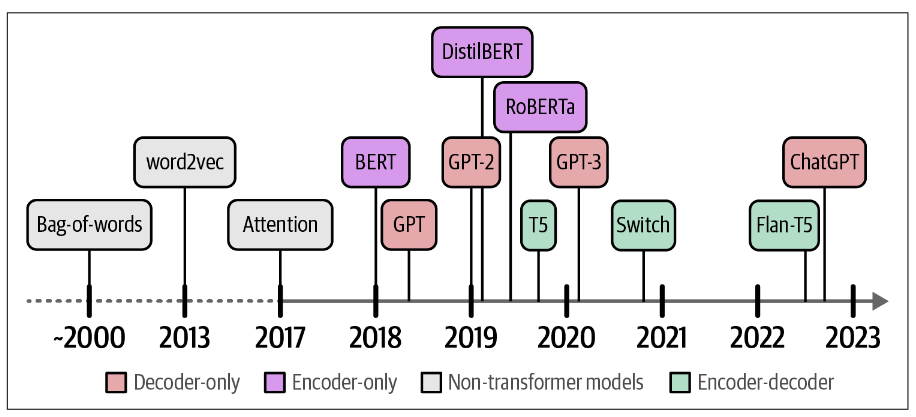

## Carga del dataset y librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Vectorizado
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.models import Word2Vec # pip install gensim==3.8.1
from sentence_transformers import SentenceTransformer # pip install sentence_transformers 
from transformers import AutoTokenizer

# Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Métricas
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Operaciones con vectores
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
url = "https://raw.githubusercontent.com/gefero/tango_scrap/refs/heads/master/Data/data_merged_raw"
df_base = pd.read_csv(url, sep = ";")

In [3]:
ritmos = df_base.ritmo_tt.value_counts().index[0:5]

f = df_base.letra_cons.notna() & df_base.ritmo_tt.isin(ritmos)
df = df_base[f].copy()
df = df.groupby("ritmo_tt").sample(157, random_state = 18)[["letra_cons", "ritmo_tt"]]
df.head()

,letra_cons,ritmo_tt
7078,nuestra calle florida es como un sueño | tal v...,cancion
143,maestro de la viola prodigiosa | curtida en la...,cancion
1030,no te vayas te lo pido | de esta casa nuestra ...,cancion
1362,domingo a las 6 | calesita es la cita | pa’ ma...,cancion
1350,por la puerta abierta que dejo porque era niña...,cancion


In [4]:
df["ritmo_tt"].value_counts()

ritmo_tt
cancion           157
milonga           157
poema lunfardo    157
tango             157
vals              157
Name: count, dtype: int64

## Baseline: TF-IDF + LogReg

In [36]:
X_train, X_test, y_train, y_test = train_test_split(df["letra_cons"], df["ritmo_tt"], test_size=0.25, random_state=18)

vectorizer = TfidfVectorizer(max_df = 0.3, min_df = 30, max_features = 1000)
X_train = vectorizer.fit_transform(X_train)

X_test = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

       cancion       0.33      0.29      0.31        41
       milonga       0.44      0.24      0.31        46
poema lunfardo       0.32      0.53      0.40        34
         tango       0.38      0.30      0.34        43
          vals       0.37      0.52      0.43        33

      accuracy                           0.36       197
     macro avg       0.37      0.38      0.36       197
  weighted avg       0.37      0.36      0.35       197



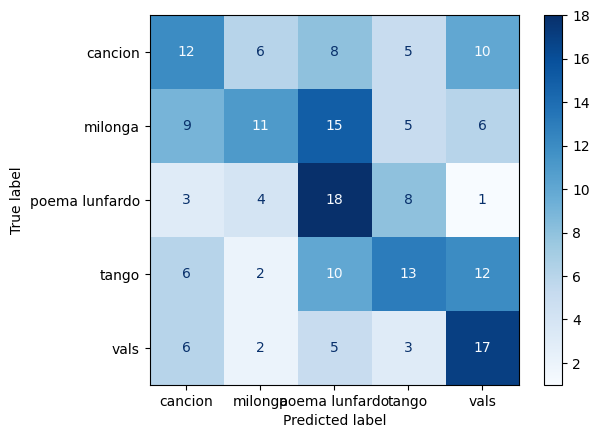

In [37]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.show()

### Interpretando coeficientes

In [79]:
feature_names = vectorizer.get_feature_names_out()

coefficients = clf.coef_

df_coef = pd.DataFrame(
    data=coefficients.T,
    index=feature_names,
    columns=clf.classes_
)

df_coef.sort_values(by = "milonga`", ascending = False).head(10)

ValueError: Shape of passed values is (206, 5), indices imply (10, 5)

## Word2Vec

La mayoría de las imágenes vienen de la presentación de Jurafsky & Martin: https://web.stanford.edu/~jurafsky/slp3/slides/vectorsemantics2024.pdf

### El problema

Tradicionalmente la lingüística piensa las palabras como una combinación de *significante* y *significado*.

El **significante** es la forma de la palabra; su sonido, en cierto modo.\
El **significado** es el sentido de la palabra, tal como podría aparecer en un diccionario, o bien, la denotación, es decir, el objeto del mundo al cual hace referencia.

Por ejemplo, la palabra perro tiene un significante, "perro", y un significado, que es el animal que nosotros conocemos como perro, los que hablan inglés como "dog", los que hablan francés como "chien", etc. Acá tenemos varias palabras con significantes distintos pero el mismo significado.

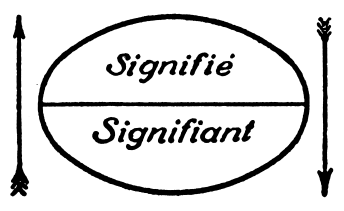

Pero esta definición de significado es data no estructurada que en principio nos sirve muy poco para hacer manipulaciones matemáticas como las que hacemos en machine learning.

El otro aspecto importante de las palabras es que independientemente de su significado (pensado como denotación o como la definición en un diccionario) ESTABLECEN DISTINTAS RELACIONES ENTRE ELLAS. Por ejemplo:

- Sinonimia: palabras son sinónimos si significan más o menos lo mismo. P. ej.: "alegría", "felicidad".
- Antonimia: son antónimos si significan más o menos lo opuesto. P. ej.: "alegría", "tristeza".
- Campo semántico: se dice que dos palabras están relacionadas cuando pertenecen al mismo campo semántico. Por ejemplo: "alegría" y "tristeza" pertencen el campo de las "emociones", si se quiere.
- Connotación: las palabras pueden tener la misma connotación; p. ej. hay una connotación negativa en las palabras "nauseabundo" y "berreta" a pesar de que no son sinónimos ni antónimos ni están relacionadas.

Este tema, el de las RELACIONES entre palabras, fíjense que es en cierto modo inmanente al sistema lingüístico, en el sentido de que no nos dice QUÉ SINGIFICA o a QUÉ HACE REFERENCIA cada palabra. Sólo nos dice cómo se relacionan entre sí.

En este sentido es un poco más fácil de estructurar y más útil para pensar en una representación matemática posible.

Sin embargo, hasta acá la representación para cada palabra que venimos usando, llamada one-hot, tampoco es tan útil. Fíjense que cada palabra es simplemente un vector con un 1 en su dimensión y 0 en todas las demás.

Además de ser poco eficiente, vemos que la diferencia entre dos palabras-vectores tan distintos como "varón" y "ortopedia" es igual a la diferencia entre "varón" y "mujer". En definitiva, esto no captura ni el significado ni la relación entre palabras.

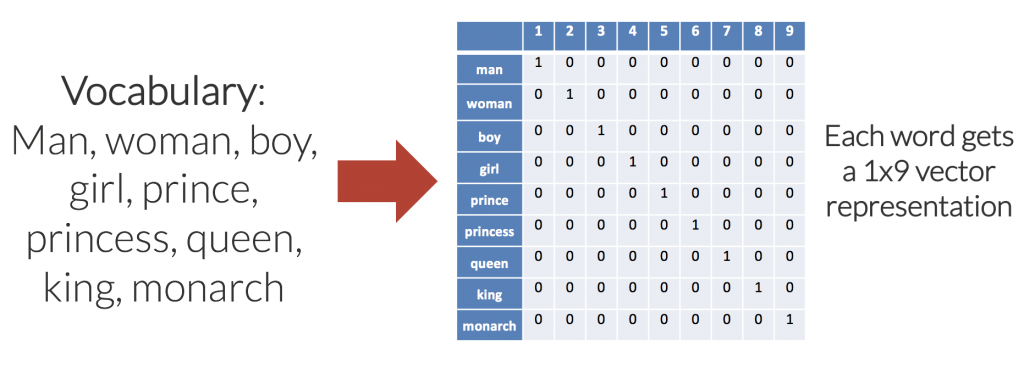

In [39]:
vectorizer = CountVectorizer(max_features = 10, max_df = 0.5)
X = vectorizer.fit_transform(df["letra_cons"])

In [40]:
vectores = pd.DataFrame(X.toarray(), columns = vectorizer.get_feature_names_out())
vectores.head()

,amor,como,es,lo,si,sin,su,te,tu,yo
0,0,6,1,0,0,1,1,0,0,0
1,0,0,1,1,0,0,0,1,4,0
2,1,0,2,1,1,0,2,5,0,0
3,0,0,4,2,0,0,2,0,0,0
4,0,0,0,1,0,2,2,2,1,1


Es cierto que en general lo que nos interesa es representar documentos antes que palabras, y en ese sentido el one-hot encoding no es tan inútil, dado que logra que documentos parecidos tengan vectores parecidos. Sin embargo, imaginemos que dos documentos hablan sobre lo mismo pero usando sinónimos... van a tener vectores distintos sin ninguna relación!

### La solución

Entonces, queremos que la representación de un documento contenga la información a priori que sabemos sobre las palabras de ese documento. Aunque cada corpus sea diferente, las palabras que se utilizan son más o menos siempre las mismas, y su significado también (si no, no nos podríamos comunicar...).

Una manera interesante de hacer esto es representar cada palabra como la cantidad de veces que aparece en un documento. Esto es lo que se llama **matriz término-documento**.

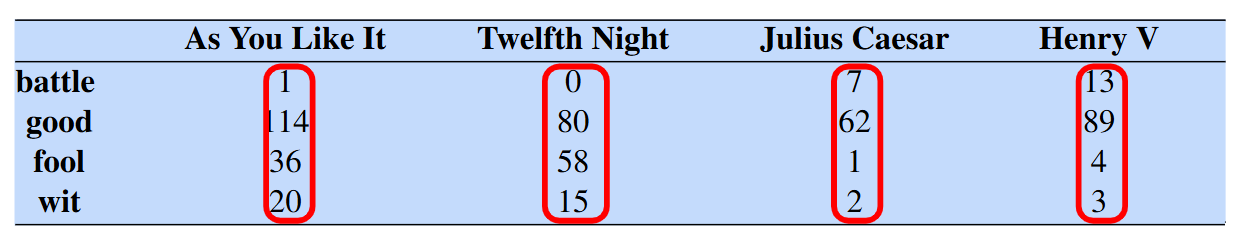

Y no es otra cosa que lo que hicimos hasta acá... transponiendo la matriz. Ahora podemos pensar cada palabra como el vector que nos dice cuántas veces aparece en cada documento de nuestro corpus.

En este caso, este vector tiene 5825 (cantidad de documentos del corpus).

In [41]:
vectores.T

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
amor,0,0,1,0,0,7,0,0,0,1,...,0,2,2,1,0,1,0,2,0,0
como,6,0,0,0,0,0,1,4,0,0,...,0,2,2,0,0,0,0,0,0,0
es,1,1,2,4,0,0,2,0,3,1,...,1,1,0,0,0,0,0,2,0,0
lo,0,1,1,2,1,0,1,0,0,1,...,1,1,0,0,0,0,4,0,0,0
si,0,0,1,0,0,3,2,0,1,2,...,1,3,0,3,1,0,1,0,0,0
sin,1,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
su,1,0,2,2,2,0,0,0,0,0,...,0,2,1,0,0,0,0,2,0,1
te,0,1,5,0,2,3,1,0,1,0,...,2,0,4,2,0,0,3,0,2,1
tu,0,4,0,0,1,1,2,2,4,4,...,2,2,8,5,8,3,3,0,1,2
yo,0,0,0,0,1,0,1,0,2,2,...,0,0,0,5,0,2,3,0,0,0


Con estos vectores podemos hacer algo interesante que es calcular la similitud entre ellos.

Dos vectores parecidos van a tener un ángulo entre ellos menor. El ángulo entre dos vectores es independiente de su magnitud, y eso es una ventaja con respecto a la distancia euclideana.

Si el ángulo es menor, el lado adyacente es mayor, y el coseno es mayor. El coseno me dice cuán parecidos son dos vectores. Cuanto mayor es el coseno, mayor es el parecido. Por eso se habla de la **similitud coseno** (que no es otra cosa que el coseno del ángulo que forman estos dos vectores).

El dot product es proporcional al coseno del ángulo y si A y B tienen longitud 1 (están normalizados), es igual al coseno del ángulo. Por eso vamos a usar el dot product como medida de similitud y vamos a asumir que cuanto mayor es el dot product, más similares son los vectores.

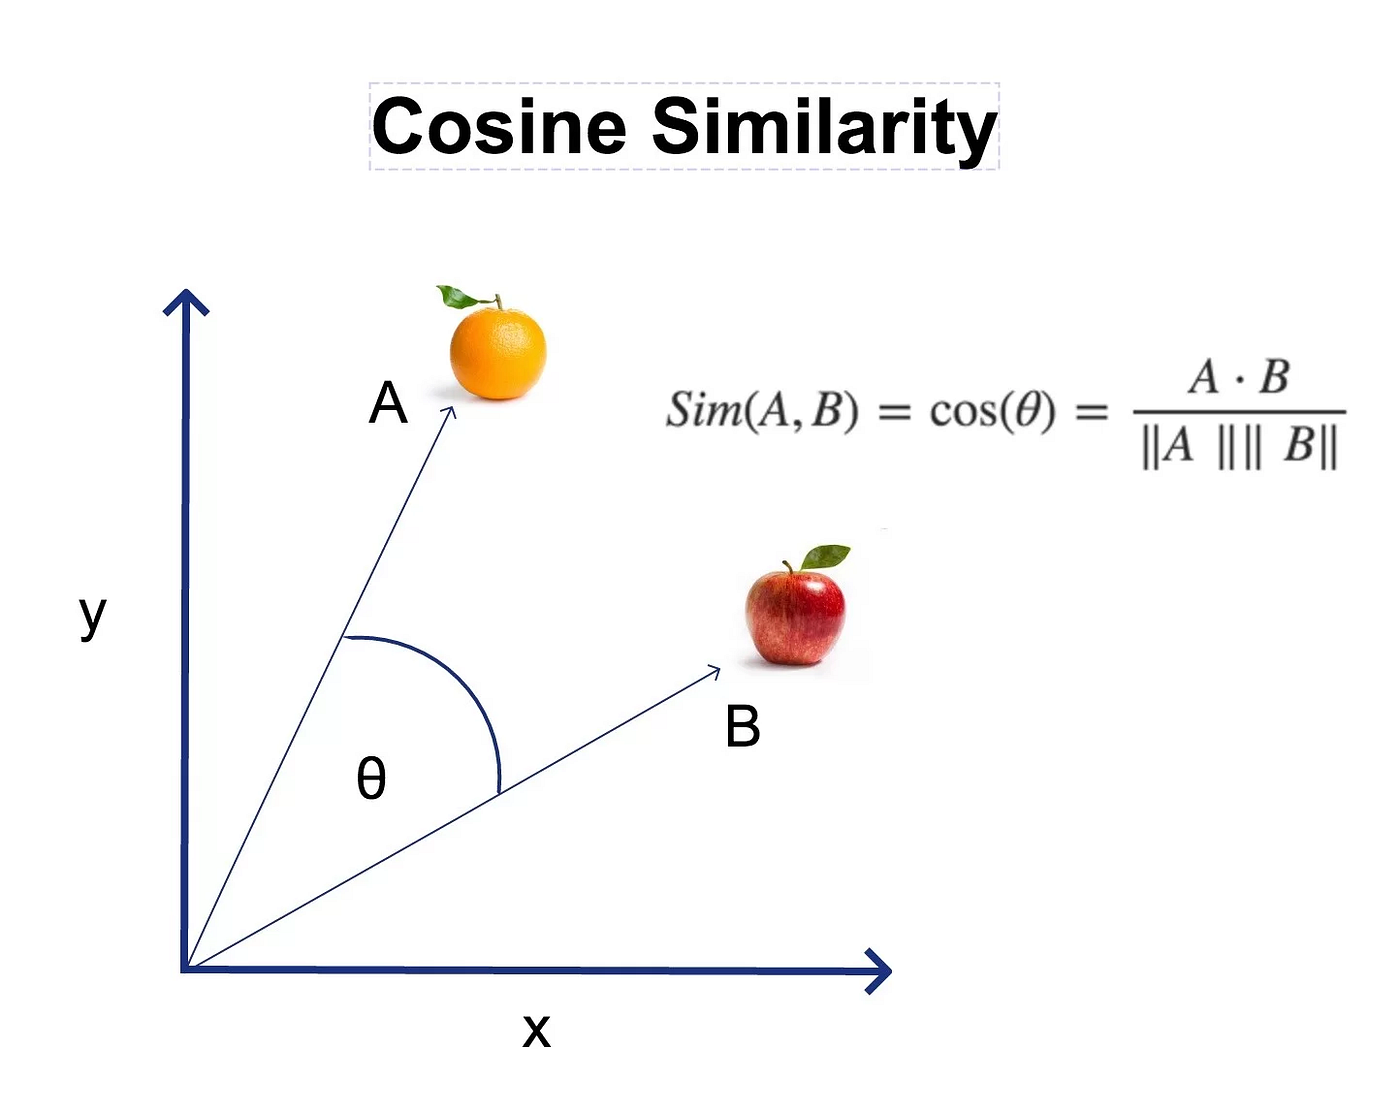

Sabemos que si el dot product = 0, los vectores son perpendiculares. Y que si es negativo, apuntan en direcciones opuestas.

In [42]:
vectores.T.loc['amor'].values

array([ 0,  0,  1,  0,  0,  7,  0,  0,  0,  1,  2,  1,  0,  0,  1,  2,  2,
        0,  0,  0,  1,  1,  0,  2,  2,  1,  1,  1,  0,  0,  2,  0,  0,  0,
        0,  0,  2,  0,  1,  0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  1,  0,
        2,  1,  1,  1,  1,  0, 10,  1,  2,  3,  2,  0,  0,  0,  2,  1,  2,
        0,  0,  0,  3,  0,  0,  0,  0,  3,  0,  6,  5,  0,  0,  0,  0,  1,
        0,  2,  0,  0,  0,  0,  0,  3,  2,  0,  0,  2,  1,  2,  2,  0,  1,
        0,  0,  0,  0,  1,  1,  0,  0,  3,  0,  1,  0,  0,  0,  1,  0,  0,
        0,  0,  0,  0,  5,  0,  0,  0,  0,  1,  0,  1,  0,  1,  0,  4,  1,
        0,  0,  1,  1,  0,  0,  0,  2,  2,  0,  3,  2,  1,  0,  0,  5,  0,
        0,  3,  0,  4,  1,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  2,
        0,  6,  0,  1,  0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  4,  0,  2,
        2,  3,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,
        0,  0,  0,  0,  0,  0,  2,  1,  0,  0,  0,  0,  0,  2,  0,  0,  2,
        0,  0,  0,  3,  0

In [43]:
amor_vector = vectores.T.loc['amor'].values.reshape(1, -1)
all_vectors = vectores.T.values
cosine_sim = cosine_similarity(amor_vector, all_vectors)

print('Cosine similarity entre "amor" y los demás vectores')
cosine_sim_series = pd.Series(cosine_sim[0], index=vectores.T.index).sort_values(ascending = False)
print(cosine_sim_series)

Cosine similarity entre "amor" y los demás vectores
amor    1.000000
tu      0.471171
yo      0.368494
si      0.320148
es      0.311101
como    0.309349
te      0.289583
sin     0.275867
su      0.250800
lo      0.245910
dtype: float64


El problema con la matriz término-documento es que sigue siendo una sparse matrix. Además, si quisiéramos enriquecer las representaciones deberíamos agregar más documentos y por ende nuevas dimensiones a nuestros vectores. Obviamente podríamos aplicar PCA y eso se ha hecho bastante.

Pero Word2vec genera estos vectores "comprimidos de otra manera". El objetivo de Word2vec va a ser crear representaciones densas (o sea, sin tantos 0) con tantas dimensiones como queramos (por defecto suelen ser 100). Cada palabra va a estar asociada entonces a un vector de 100 (o más, o menos) dimensiones.

La pregunta es: de dónde sacamos estos vectores? Para eso, la técnica que usa Word2vec es entrenar un modelo que aprende a predecir, dada una palabra target, qué palabras aparecen dentro de una ventana de contexto $m$.

$m$ es un hiperparámetro que suele ir de 2 a 5. El proceso para generar un dataset en la versión más usada de Word2vec (skip-gram con negative sampling) consiste en recorrer todo el conjunto de datos y para cada token, tomar las w palabras anteriores y las dos palabras posteriores como ejemplos de testeo positivo. Luego, tomo al azar $2m$ tokens que NO estén en el contexto y los considero ejemplos negativos. Quiero que el modelo prediga algo cercano a p = 1 dada mi context word para los ejemplos positivos, y algo cercano a p = 0 dada mi context word para los ejemplos negativos.

Notemos que, si bien hay un trainset con true labels, estas true labels se obtienen automáticamente (no hace falta poner un humano a taguear qué palabras aparecen en el contexto de la palabra target). Por eso, Word2Vec es un típico ejemplo de **APRENDIZAJE SEMI SUPERVISADO**.

Lo otro que hay que notar es que el dataset no dice nada de si la palabra context está al lado de la target a o m posiciones. Por eso se habla de una CONTINUED BAG OF WORDS, porque si bien se toma un contexto limitado, dentro de este contexto el orden de las palabras se ignora.

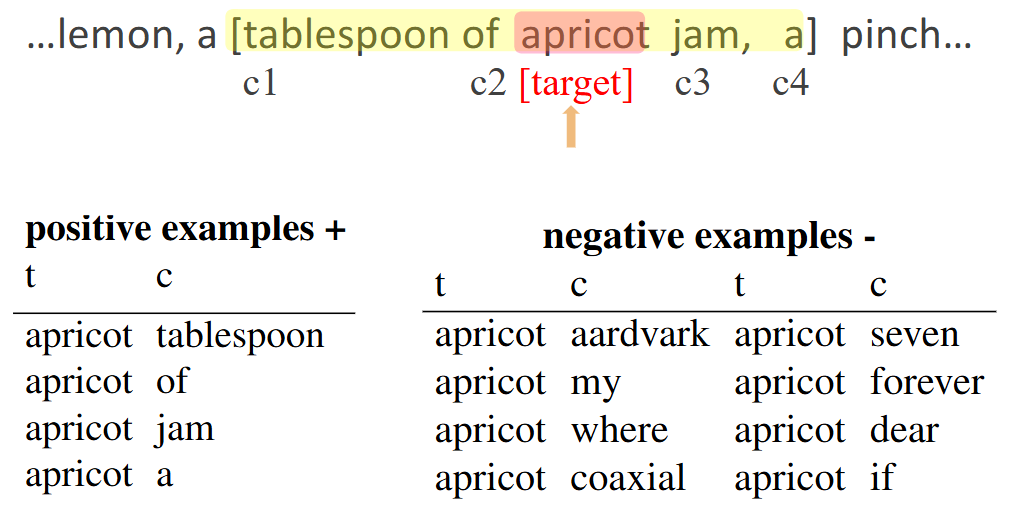

De dónde sale esta probabilidad? Esta probabilidad es el dot product entre el vector correspondiente a la target word $w$ y el vector correspondiente a la context word $c$. Luego, se mapea a probabilidad usando la función sigmoid que también usamos en la regresión logística.

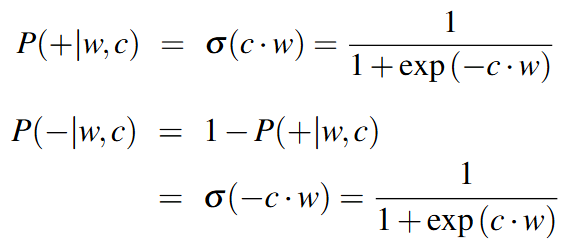

La función de costo es la misma que usamos en la regresión logística, la cross-entropy loss.

((Esto se puede pensar como una regresión logística con 200 variables para cada par target-context, donde cada caso de entrenamiento tiene dos etiquetas posibles, 1 (si aparece en el contexto) o 0 (si no aparece; lo que llamamos negative sampling))

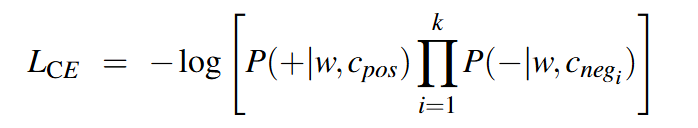

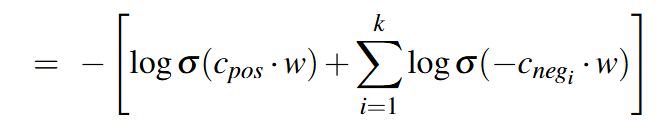

Entonces tenemos $W$ una matriz de $|V| \times dim$ para las palabras en tanto target words donde V es el vocabulario y $dim$ es un hiperparámetro que me dice con cuántas dimensiones quiero describir cada palabra. O sea que en $W$, cada fila corresponde a una palabra de nuestro vocabulario, y las columnas son las dimensiones entrenables (en general 100). Que quede claro: las palabras que corresponden a cada matriz SON LAS MISMAS, pero en cierto modo cada matriz representa a esas palabras en tanto contexto o en tanto target.

$C$ también es una matriz de shape $|V| \times dim$ pero corresponde a las palabras en tanto context words.

Ambas matrices son entrenables. 
Notemos: NO VAMOS A USAR EL MODELO PARA PREDECIR, sino que es una **TAREA DE PRETEXTO**. Después lo que nos importa es quedarnos con los pesos (las matrices $W$ y $C$ entrenadas) para usarlas como forma de representar nuestras palabras en otras tareas como clasificación.

Esto significa que tenemos dos vectores de largo $dim$ para cada palabra, un vector target $w$ que sale de $W$ y otro context $c$ que sale de $C$ (la fila correspondiente a cada palabra viene de un vector one-hot como los que ya conocemos).

En la práctica muchas veces se descarta el vector context o el vector target, o se suman o promedian ambos, para tener un solo vector por palabra.

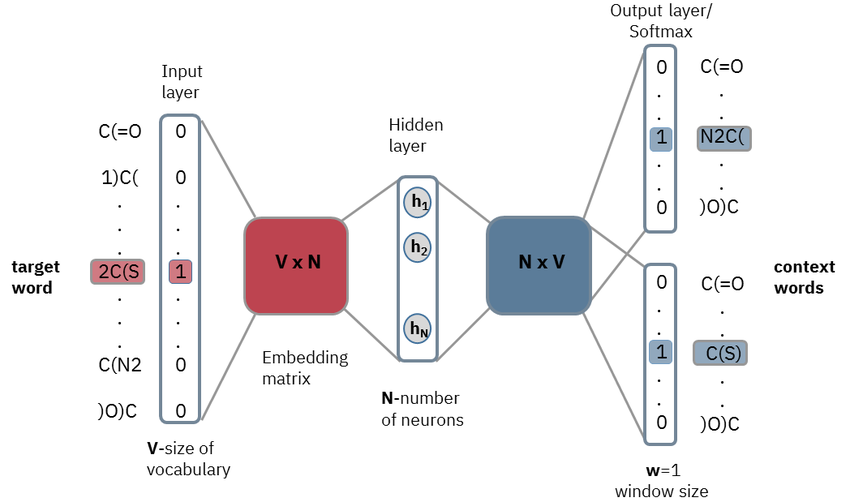

Como consecuencia de esto, palabras que aparecen en contextos parecidos van a tener vectores parecidos. Por ejemplo, todas las palabras que aparezcan en un contexto como: "el _ ladra" deberían ser semejantes.

Mejor aún: hay GRADOS de similitud. Variantes ortográficas de una misma palabra (por ejemplo, "hola" y "ola") van a ser probablemente más parecidas que sinónimos ("hola", "buenas").

En principio, cuando $m = 2$, los vectores similares se parecen más "sintácticamente" (por ejemplo los sustantivos comunes suelen ir acompañados de un artículo como "la" o "el" y de algún verbo, que podría ser "es"), mientras que si hacemos $m$ un poco más grande, se parecen en términos de campo semántico.

Word2vec logra llevar a la práctica la definición de significado que tradicionalmente había defendido la SEMÁNTICA DISTRIBUCIONAL. P.ej. un viejo lingüista llamado John Rupert Firth escribió en 1957 una frase que aparece siempre citada en el contexto de Word2vec: "You shall know a word by the company it keeps". Estas ideas también sintonizan muy bien con las ideas de Wittgenstein, que proponía: "The meaning of a word is its use in the language".

### Implementación con Gensim

Vamos a ver con un testset de juguete qué pasa.

In [44]:
sentences = [["pedro", "estudia", "letras"], ["ana", "estudia", "arte"]] # Gensim pide este tipo de dato, cada documento es una lista de palabras ordenadas

vector_size = 2 # Esto es dim, la cantidad de dimensiones con las cuales vamos a querer representar cada palabra
window = 2 # Esto es m, la cantidad de palabras a izquierda y derecha de la palabra target que se tienen en cuenta
negative = 5 # La cantidad de negative samples que se toman
max_vocab_size = 5000 # la cantidad de palabars para las cuales vamos a obtener un vector. Si estoy usando un corpus muy grande no quiero entrenar un vector para todas las palabras, probablemente. Entonces con este parámetro me voy a quedar con las más frecuentes
min_count = 1

model = Word2Vec(sentences=sentences, vector_size=vector_size, window=window, min_count=min_count, compute_loss = True)

# Una vez que tenemos entrenado el modelo, podemos acceder a los vectores de cada palabra con el atributo wv
# Este atributo es un tipo de dato propio de Gensim llamado KeyedVectors que lo que tiene de piola es que es independiente del modelo con el que se obtuvieron los vectores, y además ofrece una serie de métodos interesantes que simplifican la operatoria con vectores
word_vectors = model.wv
print(word_vectors)
print(word_vectors.index_to_key)
print("Todos los vectores:\n", word_vectors.vectors)
print("Vector para ana:\n", word_vectors["ana"])
print("Vector para ana y pedro:\n", word_vectors["ana", "pedro"]) # Puedo obtener varios vectores a la vez

KeyedVectors<vector_size=2, 5 keys>
['estudia', 'arte', 'ana', 'letras', 'pedro']
Todos los vectores:
 [[-0.02681136  0.01182157]
 [ 0.25516748  0.45046365]
 [-0.4651475  -0.35584044]
 [ 0.32294363  0.4486494 ]
 [-0.2507714  -0.18816859]]
Vector para ana:
 [-0.4651475  -0.35584044]
Vector para ana y pedro:
 [[-0.4651475  -0.35584044]
 [-0.2507714  -0.18816859]]


In [45]:
model.get_latest_training_loss()

4.231315612792969

Vamos a plotear las palabras en un gráfico 2D (tiene sentido porque elegimos dim = 2; caso contrario convendría reducir dimensionalidad).

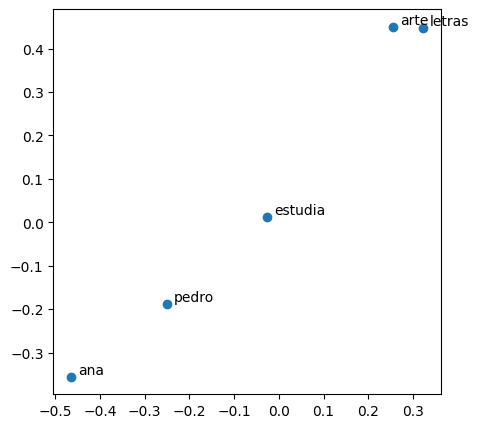

In [46]:
words = list(model.wv.index_to_key)
vectors = model.wv[words]

plt.figure(figsize=(5, 5))
plt.scatter(vectors[:, 0], vectors[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(vectors[i, 0], vectors[i, 1]), xytext=(5, 2), textcoords='offset points')

plt.show()

### Transfer learning

Una de las grandes ventajas que habilita Word2vec es la posibilidad de hacer transfer learning, esto es, de usar los pesos de modelos preentrenados para nuestras "downstream tasks" (por ejemplo, clasificar). Es decir, en la práctica no vamos generalmente a entrenar un modelo de cero, sino que vamos a buscar alguno ya existente y vamos a extraer las features de ahí.

In [47]:
import gensim.downloader as api

api.info().keys()

dict_keys(['corpora', 'models'])

In [48]:
api.info()['models']['glove-wiki-gigaword-50']

{'num_records': 400000,
 'file_size': 69182535,
 'base_dataset': 'Wikipedia 2014 + Gigaword 5 (6B tokens, uncased)',
 'reader_code': 'https://github.com/RaRe-Technologies/gensim-data/releases/download/glove-wiki-gigaword-50/__init__.py',
 'license': 'http://opendatacommons.org/licenses/pddl/',
 'parameters': {'dimension': 50},
 'description': 'Pre-trained vectors based on Wikipedia 2014 + Gigaword, 5.6B tokens, 400K vocab, uncased (https://nlp.stanford.edu/projects/glove/).',
 'preprocessing': 'Converted to w2v format with `python -m gensim.scripts.glove2word2vec -i <fname> -o glove-wiki-gigaword-50.txt`.',
 'read_more': ['https://nlp.stanford.edu/projects/glove/',
  'https://nlp.stanford.edu/pubs/glove.pdf'],
 'checksum': 'c289bc5d7f2f02c6dc9f2f9b67641813',
 'file_name': 'glove-wiki-gigaword-50.gz',
 'parts': 1}

In [49]:
word_vectors = api.load('glove-wiki-gigaword-50')  # vamos a descargarnos directamente unos KeyedVectors (no el modelo en sí)

In [50]:
print("Tenemos", len(word_vectors.index_to_key), "palabras únicas")
print("Cada palabra está representada por un vector de", word_vectors[0].shape[0], "dimensiones")
word_vectors[0]

Tenemos 400000 palabras únicas
Cada palabra está representada por un vector de 50 dimensiones


array([ 4.1800e-01,  2.4968e-01, -4.1242e-01,  1.2170e-01,  3.4527e-01,
       -4.4457e-02, -4.9688e-01, -1.7862e-01, -6.6023e-04, -6.5660e-01,
        2.7843e-01, -1.4767e-01, -5.5677e-01,  1.4658e-01, -9.5095e-03,
        1.1658e-02,  1.0204e-01, -1.2792e-01, -8.4430e-01, -1.2181e-01,
       -1.6801e-02, -3.3279e-01, -1.5520e-01, -2.3131e-01, -1.9181e-01,
       -1.8823e+00, -7.6746e-01,  9.9051e-02, -4.2125e-01, -1.9526e-01,
        4.0071e+00, -1.8594e-01, -5.2287e-01, -3.1681e-01,  5.9213e-04,
        7.4449e-03,  1.7778e-01, -1.5897e-01,  1.2041e-02, -5.4223e-02,
       -2.9871e-01, -1.5749e-01, -3.4758e-01, -4.5637e-02, -4.4251e-01,
        1.8785e-01,  2.7849e-03, -1.8411e-01, -1.1514e-01, -7.8581e-01],
      dtype=float32)

In [51]:
word_vectors.most_similar("cat")[0:5]

[('dog', 0.9218006134033203),
 ('rabbit', 0.8487821221351624),
 ('monkey', 0.8041081428527832),
 ('rat', 0.7891963124275208),
 ('cats', 0.7865270972251892)]

In [52]:
word_vectors.most_similar("cats")[0:5] # Es interesante que los plurales no sean tan similares a los singulares

[('dogs', 0.8516519665718079),
 ('rabbits', 0.8350488543510437),
 ('animals', 0.799648106098175),
 ('cat', 0.7865270376205444),
 ('elephants', 0.7847661375999451)]

In [53]:
word_vectors.most_similar(positive=['woman', 'king'], negative=['man'])[0:5]

[('queen', 0.8523604273796082),
 ('throne', 0.7664334177970886),
 ('prince', 0.7592144012451172),
 ('daughter', 0.7473883628845215),
 ('elizabeth', 0.7460219860076904)]

In [54]:
word_vectors.most_similar(positive=['girl', 'batman'], negative=['man'])[0:5]

[('catwoman', 0.8012676239013672),
 ('superman', 0.7201690673828125),
 ('superboy', 0.7134482264518738),
 ('supergirl', 0.7022400498390198),
 ('nightwing', 0.6911354064941406)]

In [55]:
word_vectors.most_similar(positive=['cats', 'dog'], negative=['cat'])[0:5] # Dirección que codifica el plural

[('dogs', 0.9040207862854004),
 ('animals', 0.7858268022537231),
 ('rabbits', 0.7637406587600708),
 ('goats', 0.7345797419548035),
 ('cows', 0.734263002872467)]

In [56]:
word_vectors.most_similar(positive=['arsenal', 'spain'], negative=['england'])[0:5]

[('madrid', 0.7326223254203796),
 ('sevilla', 0.714796245098114),
 ('barcelona', 0.710261881351471),
 ('villarreal', 0.7066751718521118),
 ('espanyol', 0.7033568620681763)]

In [57]:
print(word_vectors.similarity('argentina', 'brazil'))
print(word_vectors.similarity('argentina', 'france'))

0.8712695
0.6406353


In [58]:
word_vectors.doesnt_match(["apple","oranges","soccer"])

'soccer'

### Un modelo en español

In [59]:
from huggingface_hub import hf_hub_download

repo_id = "fcalabro/wiki_es_m18"
filename = "w2v_wiki_es_m18.kv"

model_path = hf_hub_download(repo_id=repo_id, filename=filename, local_dir=".")

In [60]:
from gensim.models.keyedvectors import KeyedVectors

word_vectors_sp = KeyedVectors.load("w2v_wiki_es_m18.kv")

In [61]:
word_vectors_sp.most_similar(positive=['mujer', 'rey'], negative=['hombre'])[0:5]

[('reina', 0.8342541456222534),
 ('alfonsovi', 0.804561197757721),
 ('berenguela', 0.8012315630912781),
 ('adosinda', 0.7879668474197388),
 ('muniadona', 0.784090518951416)]

In [67]:
word_vectors_sp.most_similar(positive=['gatos', 'perro'], negative=['gato'])[0:5]

[('perros', 0.8854379057884216),
 ('conejos', 0.796785831451416),
 ('cerdos', 0.7965547442436218),
 ('carroña', 0.7950847148895264),
 ('jabalíes', 0.7930832505226135)]

In [62]:
word_vectors_sp.most_similar("gatos")[0:5]

[('perros', 0.9082281589508057),
 ('piojos', 0.8573277592658997),
 ('conejos', 0.8566129803657532),
 ('ratones', 0.8312597274780273),
 ('roedores', 0.8239379525184631)]

### De la palabra a la oración

In [68]:
tfidf_vectorizer = TfidfVectorizer(lowercase=True)
tfidf_vectorizer.fit(df["letra_cons"])

idf_dict = dict(zip(tfidf_vectorizer.get_feature_names_out(),
                    tfidf_vectorizer.idf_))

def sent_vec_weighted_sp(sentence):
    words = sentence.lower().split()
    vecs = []
    for w in words:
        if w in word_vectors_sp.key_to_index:
            weight = idf_dict.get(w, 1.0)
            vecs.append(word_vectors_sp[w] * weight)
    if not vecs:
        return np.zeros(word_vectors_sp.vector_size)
    return np.mean(vecs, axis=0).reshape(1, -1)

In [69]:
df.loc[:, "w2v_es"] = df["letra_cons"].apply(sent_vec_weighted_sp)

In [70]:
df.loc[:, "w2v_es"].iloc[0]

array([[-0.01801724, -0.3516387 , -0.5521871 ,  0.8037757 , -1.0033585 ,
        -0.6615625 ,  0.26520705,  1.5728598 , -1.1100031 , -1.4848157 ,
         0.16740438,  0.31190148, -0.41627276,  0.22901984,  0.49615878,
         0.9612752 ,  0.62738186,  1.4114078 , -1.4766243 , -0.92990524,
         0.18210696,  0.42834625,  1.0746661 ,  0.30602214,  0.59507793,
         1.4693635 , -0.8316506 ,  0.16089742, -0.36586514, -0.05076011,
         0.07141788, -0.999808  ,  0.19018553, -1.3403782 , -0.17709856,
         0.1254172 ,  2.049727  ,  0.55104154, -0.515289  ,  0.52192473,
         0.28261262,  0.26500583,  0.728145  , -0.01196211,  1.0233417 ,
         0.40655738, -0.00535162, -0.65458673,  0.3579008 ,  0.7114788 ]],
      dtype=float32)

### Entrenamiento

In [71]:
X = np.vstack(df["w2v_es"])
y = df["ritmo_tt"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=18)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))

                precision    recall  f1-score   support

       cancion       0.37      0.32      0.34        41
       milonga       0.35      0.26      0.30        46
poema lunfardo       0.42      0.68      0.52        34
         tango       0.47      0.33      0.38        43
          vals       0.37      0.48      0.42        33

      accuracy                           0.40       197
     macro avg       0.40      0.41      0.39       197
  weighted avg       0.40      0.40      0.38       197



## Hacia representaciones contextuales

Un problema de esta forma de obtener embeddings es que, por ejemplo, la oracíón "River venció a Boca" se representa igual que la oración "Boca venció a River".

In [73]:
np.array_equal(sent_vec_weighted_sp("river venció a boca").round(2),sent_vec_weighted_sp("boca venció a river").round(2))

True

Ignorar el orden de las palabras (el contexto) en el caso del lenguaje es resignarse a perder muchísima información valiosa. Por eso en la década del 2010 se empiezan a usar un tipo de redes llamadas recurrentes (RNN) y variantes de esta arquitectura. Las RNNs "modelan" una secuencia teniendo en cuenta esta lógica temporal. La idea dees que las activaciones de la capa oculta sean una combinación de la entrada actual y la capa oculta calculada en el paso anterior.

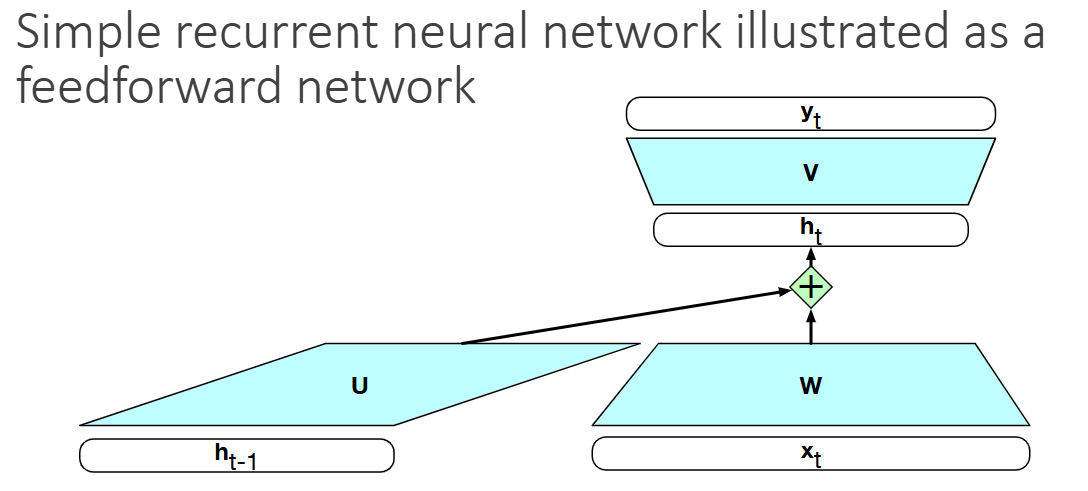

Entonces por ejemplo, si tenemos una oración como "Juan vio a Pedro", vamos a tener cuatro "pasos". En el primero se multiplica el vector correspondiente a "Juan" (que podría provenir de un embedding como Word2Vec) y la capa oculta, como una red normal. El segundo paso se multiplica el vector de la capa oculta anterior por los weights, y se suma esto a la multiplicación de la nueva entrada, "vio", por sus weights.

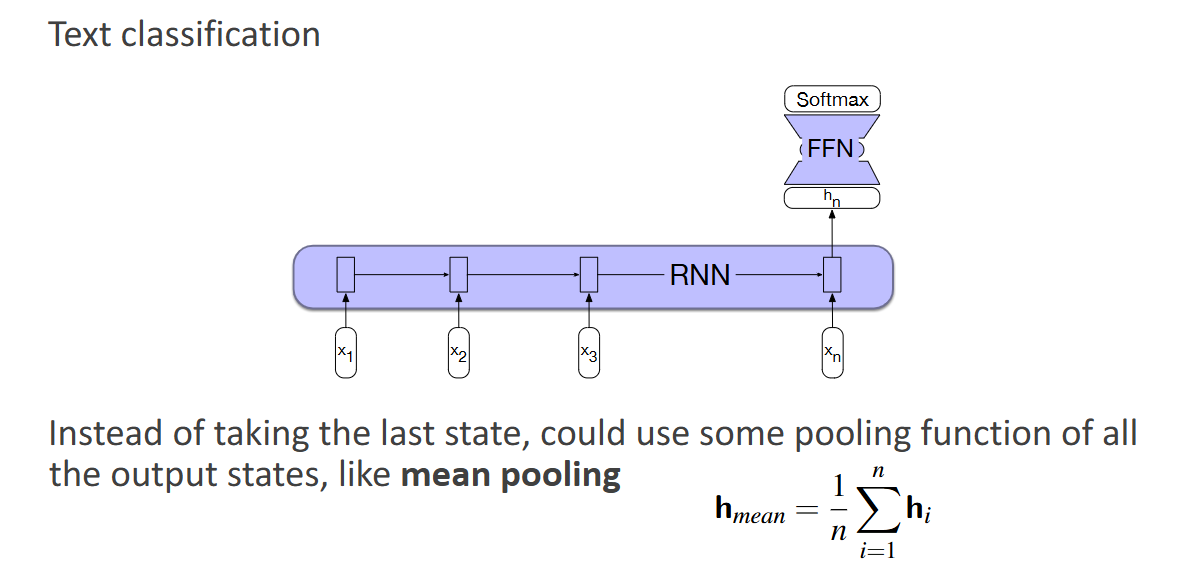

Cuando usamos una RNN para clasificar una secuencia, por cada palabra de esa secuencia vamos a tener un nuevo vector de activaciones. ¿Con cuál nos quedamos? Una opción es quedarnos con el de la última palabra, que se supone que ya "incluye" información de todas las palabras anteriores. La otra es hacer el promedio (mean pooling).

### Encoder-decoder

La del encoder-decoder es un tipo de arquitectura pensada para traducir una secuencia en otra secuencia. Típicamente esto se usa para traducción automática. Con RNNs, al momento de la inferencia (de la traducción), lo que voy a hacer es usar las activaciones correspondientes a la última palabra en mi idioma original, luego agregar un token especial llamado "separator" o \<sos\> (por "start of sequence") (que yo usé en mi entrenamiento) y usar eso para generar la oración traducida.

!! Notemos que no se traduce "palabra por palabra" y que no hay un límite en el largo de la oración traducida. La traducción termina cuando la RNN solita predice un token de final de secuencia (llamado generalmente \<eos\>), que en términos técnicos es igual a cualquier otro token.

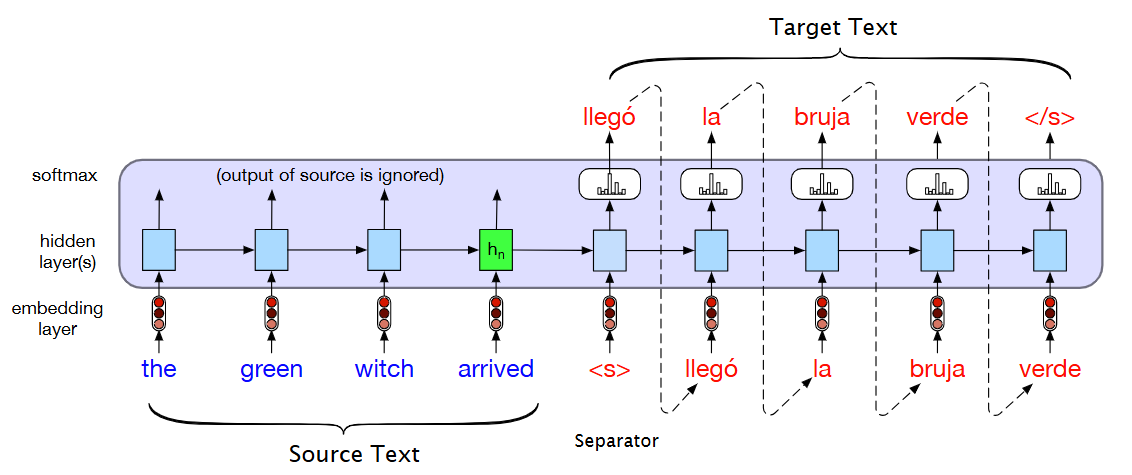

### Atención

Notemos que, si bien estamos traduciendo -y modelando en general- oraciones, en la práctica lo que yo tengo son tokens individuales, y activaciones para cada uno de esos tokens.

Dijimos también que las RNNs permitían darle a cada token una representación vectorial "contextual", que era una especie de "suma" entre las activaciones del token anterior y sus propias activaciones (que en general salen de multiplicar un vector de embeddings estático preentrenado con Word2vec por los weights de la RNN).

Esto es una gran idea, pero se encontró que esa capa de activaciones que iba acumulando los "significados" de la secuencia tenía sus limitaciones. Se generaba una especie de "cuello de botella" porque, intuitivamente, no podía acumular TODOS los matices de una oración. En particular se observaron problemas con lo que en sintaxis se llama "dependencias de larga distancia", como en oraciones del tipo: "El veterinario que vio a mi perro cuando tuvo su episodio de rabia me explicó que..." (las RNNs "olvidan" el sujeto de la oración).

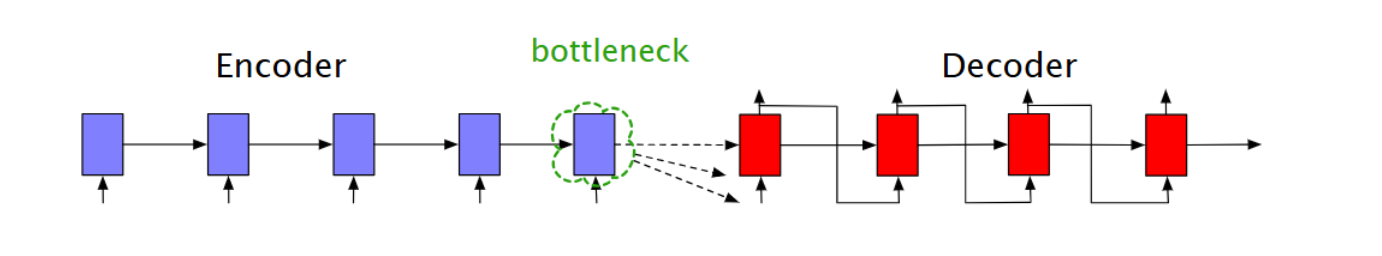

Intuitivamente, este algoritmo hace que la representación del estado (token) i sea una combinación entre el hidden state de i (llamado query vector) y una suma ponderada de la representación de todos los estados (llamada key vector), donde esta ponderación depende de cuán similares (en términos de dot product) son el estado de i-1 y todos los estados anteriores.

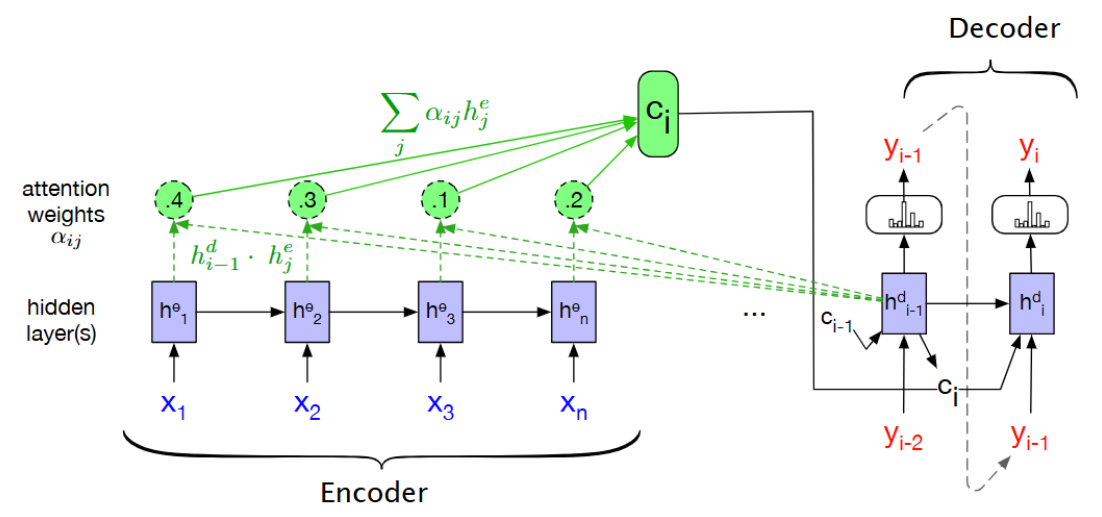

A partir de esta idea fundamental surgen distintas innovaciones:

- **Encoder-only**: Yo puedo usar solamente la parte del encoder para obtener una representación vectorial de los tokens (ya no quiero traducir, sólo vectorizar). En este caso, aprovecho el mecanismo de la atención para comparar la similitud entre los tokens en el "idioma original". La representación para cada token es una mezcla de información estática (word2vec) más una información contextual. Esta información viene del positional embedding (valores que dependen de la posición de cada palabra) más una suma ponderada de las representaciones de los otros tokens de la oración. Acá la suma es "bidireccional" (por eso BERT: Bidirectional Encoder Representations from Transformer), es decir que ya no tengo en cuenta el estado i-1 para calcular el estado i.

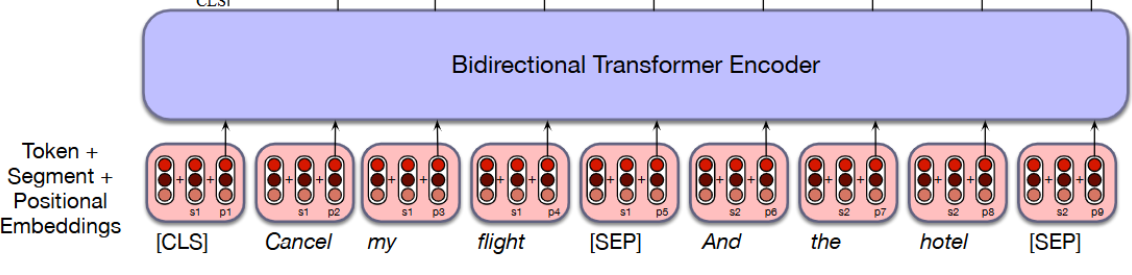

- **Decoder-only**: Ahora uso esta arquitectura para GENERAR texto. Voy generando un token a la vez, en forma "auto-regresiva". Cada token nuevo atiende a los tokens anteriores. Elijo el nuevo token agregando una red neuronal feed-forward sobre la representación del último token, que me da una distribución de probabilidad para todos los tokens de mi vocabulario. 

## SentenceTransformers

BERT me daba una representación para cada token de mi oración. Además del problema de cómo representar la oración a partir de sus componentes (¿con un promedio?, ¿con el último token?, ¿con el primero?), el punto es que BERT no estaba entrenado específicamente para generar buenas representaciones oracionales; su tarea de pretexto era predecir la siguiente palabra (next-token prediction).

SentenceTransformers es una familia de modelos que lo que hacen es tomar las representaciones de BERT, hacer un promedio para todos los tokens y finetunear los parámetros de BERT de tal forma que el promedio resultante me sirva para que:
- Oraciones parecidas tengan vectores parecidos (en términos de cosine similarity, o sea un dot product alto)
- Oraciones diferentes tengan vectores diferentes.

Es decir que el dataset de entrenamiento de un modelo SentenceTransformers consta de pares de oraciones similares y distintas.

![alt text](image-3.png)

En https://www.sbert.net/docs/sentence_transformer/pretrained_models.html se puede encontrar una lista de "modelos oficiales" (también se pueden usar extra-oficiales de HuggingFace).

Vamos a probar con el `distiluse-base-multilingual-cased-v1` que fue entrenado con data en varios idiomas, incluido el español.

In [74]:
st_vectorizer = SentenceTransformer("distiluse-base-multilingual-cased-v1", cache_folder = ".")

In [75]:
config = st_vectorizer._first_module().auto_model.config

print("Modelo base:", config._name_or_path)
print("Número de attention heads:", config.num_attention_heads)
print("Dimensión del embedding:", config.hidden_size)
print("Tamaño máximo de secuencia:", config.max_position_embeddings)

Modelo base: sentence-transformers/distiluse-base-multilingual-cased-v1
Número de attention heads: 12
Dimensión del embedding: 768
Tamaño máximo de secuencia: 512


In [76]:
np.array_equal(st_vectorizer.encode("river venció a boca").round(2), st_vectorizer.encode("boca venció a river").round(2))

False

In [77]:
tokenizer = AutoTokenizer.from_pretrained(config._name_or_path)

texto = "river venció a boca"

tokens = tokenizer(texto, return_tensors="pt")

print(tokens["input_ids"])

print(tokenizer.convert_ids_to_tokens(tokens["input_ids"][0]))

tensor([[  101, 16965, 26044, 11174,   169, 46478,   102]])
['[CLS]', 'river', 'ven', '##ció', 'a', 'boca', '[SEP]']


In [78]:
X = st_vectorizer.encode(df["letra_cons"].values, show_progress_bar=True)
y = df["ritmo_tt"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=18)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, zero_division=0))

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

                precision    recall  f1-score   support

       cancion       0.39      0.34      0.36        41
       milonga       0.38      0.22      0.28        46
poema lunfardo       0.41      0.65      0.50        34
         tango       0.39      0.26      0.31        43
          vals       0.34      0.55      0.42        33

      accuracy                           0.38       197
     macro avg       0.38      0.40      0.37       197
  weighted avg       0.38      0.38      0.36       197



# Consignas TP 3 (15/09)

En este trabajo hay que aplicar un pipeline completo de clasificación; o sea, vectorizado + modelo de clasificación. Recuerden incorporar el preprocesado de texto que hicieron en el primer TP.

Para vectorizar, deben probar estas técnicas:
1) Feature engineering. Para eso pueden elegir entre 2 y 20 variables que crean significativas a partir de la exploración que han hecho del corpus. 
2) CountVectorizer/Tf-Idf (una de las dos).
3) Word2vec/Sentence-Transformers (una de las dos, o ambas). Acá verán que hay muchos modelos para elegir en internet (sobre todo en el caso de ST; fíjense por ejemplo [jina-embeddings](https://huggingface.co/collections/jinaai/jina-embeddings-v2-65708e3ec4993b8fb968e744)). Pueden explorar distintos modelos de ST (oficiales o "de la comunidad") o pueden usar el que vimos en esta notebook. También, para el caso de Word2Vec, pueden probar distintas formas de obtener las features para cada oración.

Luego, en cada caso deberán entrenar uno o más modelos. Para que los resultados sean comparables, usen los mismos modelos en todos los casos, y mantengan siempre la misma partición de entrenamiento/test (recuerden setear el random state!). Tomen como baseline la regresión logística y luego siéntanse libres de explorar lo que hayan visto en otras materias (pueden sumar un SVM o un MLP, pero también sería muy divertido usar un árbol de decisión para las técnicas 1 y 2). Pueden usar búsqueda de hiperparámetros si quieren.

Además:
- Para el caso de la regresión logística + feature engineering o BOW, interpretar los coeficientes.
- Para el modelo más exitoso, inspeccionar los errores y dar una posible explicación del porqué de la dificultad del modelo para clasificar esas canciones.
- Luego de hacer las pruebas con los diferentes modelos, redactar una conclusión indicando cuál fue el pipeline más exitoso y por qué creen que fue así. ¿Qué tuvo más peso en los resultados: la manera de vectorizar o el modelo de clasificación?

_Opcional_: Mediante la técnica de feature extraction que prefieran, corran un clustering (K-means o de otro tipo) e inspeccionen los resultados. ¿Aparecen clusters interpretables? ¿Son más o menos interesantes que los que nos dio LDA?

#### Aclaraciones
- Si la notebook que entregan no parte del [dataset de Github](https://github.com/fcalabrow/diplodatos_lacuerda/blob/main/dataset.csv), sino que suben otro dataset ya preprocesado, éste tiene que poder ser descargado desde la notebook (pueden subirlo a Github o a Google Drive, pero el link tiene que ser público).
- Recuerden que el código no se explica solo; vayan comentando sucintamente qué es lo que están haciendo en cada celda, y justifiquen las decisiones que toman.
- Si el dataset que usan está desbalanceado, tengan en cuenta usar las métricas adecuadas para que las conclusiones sean válidas.

Este TP se entrega el 15/09, y el 29/09 es la fecha de entrega del video final.

# Material de consulta
- _Speech and Language Processing_, de Dan Jurafsky y James H. Martin. Libro disponible online: https://web.stanford.edu/~jurafsky/slp3/
- _Hands-On Large Language Models_, de Jay Alammar y Maarten Grootendorst. Libro: https://www.llm-book.com/
- "The Illustrated BERT, ELMo, and co. (How NLP Cracked Transfer Learning)", de Jay Alammar. Blogpost: https://jalammar.github.io/illustrated-bert/
- "Transformer Explainer", página web creada por Aeree Cho et al. con una demo muy visual de GPT-2: https://poloclub.github.io/transformer-explainer/
- "Transformers, the tech behind LLMs", serie de videos de 3blue1brown: https://youtu.be/wjZofJX0v4M?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi
- Documentación de Gensim: https://radimrehurek.com/gensim/models/word2vec.html
- Documentación de SentenceTransformers: https://www.sbert.net/index.html